# Heuristic Offset Sweep: With vs Without Handover Control

This notebook runs many controlled tests for the lower heuristic in the 3-gNB environment. Each test starts from the same scenario and seed, compares a radio-only baseline against a fixed-bias heuristic rollout, and reports the extra effect caused by heuristic offsets/handovers.

Rows in bias matrices are gNBs `0, 1, 2`; columns are `eMBB, URLLC, mMTC`. Negative bias on a serving gNB/slice encourages offload. Positive bias encourages retention.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "global_ppo_3gnb_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from global_ppo_3gnb_env import GLOBAL_SNAPSHOT_SCENARIOS, GlobalPPO3GNBEnv, SLICE_TYPES

plt.rcParams.update({"figure.dpi": 125, "axes.grid": True, "grid.alpha": 0.22})
np.set_printoptions(precision=3, suppress=True)

GNB_IDS = [0, 1, 2]
print(f"Project root: {PROJECT_ROOT}")
print("Slices:", SLICE_TYPES)

Project root: /home/oussama/Desktop/RL_juin
Slices: ('eMBB', 'URLLC', 'mMTC')


## Experiment Setup

The default custom target starts with gNB0 eMBB at `0.80` and the other eMBB cells at `0.20`. UE counts are fixed to 5 per slice, 15 total.

In [2]:
SCENARIO_NAME = "embb_g0_offload"
USE_CUSTOM_TARGET_MATRIX = True
CUSTOM_TARGET_MATRIX = np.array([
    [0.80, 0.20, 0.20],
    [0.20, 0.20, 0.20],
    [0.20, 0.20, 0.20],
], dtype=float)

CUSTOM_UE_COUNTS = pd.DataFrame(
    [[3, 1, 1], [1, 2, 2], [1, 2, 2]],
    index=[f"gNB {g}" for g in GNB_IDS],
    columns=SLICE_TYPES,
)

N_WINDOWS = 6
LOCAL_STEPS_PER_GLOBAL = 10
MAX_HANDOVERS_PER_LOCAL_STEP = 1
SEEDS = [7, 11, 19]

target_matrix = CUSTOM_TARGET_MATRIX.copy() if USE_CUSTOM_TARGET_MATRIX else np.asarray(GLOBAL_SNAPSHOT_SCENARIOS[SCENARIO_NAME], dtype=float)
display(pd.DataFrame(target_matrix, index=CUSTOM_UE_COUNTS.index, columns=SLICE_TYPES).style.set_caption("Target load matrix"))
display(CUSTOM_UE_COUNTS.style.set_caption(f"Custom UE counts, total={int(CUSTOM_UE_COUNTS.to_numpy().sum())}"))

,eMBB,URLLC,mMTC
gNB 0,0.800000,0.200000,0.200000
gNB 1,0.200000,0.200000,0.200000
gNB 2,0.200000,0.200000,0.200000


,eMBB,URLLC,mMTC
gNB 0,3,1,1
gNB 1,1,2,2
gNB 2,1,2,2


## Bias Sweep Definitions

`g0_eMBB_offload_strength` applies negative bias to gNB0/eMBB and positive bias to gNB1/gNB2/eMBB. The sweep tests weak through strong control.

In [3]:
def g0_embb_bias(strength):
    strength = float(strength)
    return np.array([
        [-strength, 0.0, 0.0],
        [ strength, 0.0, 0.0],
        [ strength, 0.0, 0.0],
    ], dtype=float)

def all_slice_g0_bias(strength):
    strength = float(strength)
    return np.array([
        [-strength, -strength, -strength],
        [ strength,  strength,  strength],
        [ strength,  strength,  strength],
    ], dtype=float)

BIAS_TESTS = []
for strength in [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.60, 0.80, 1.0]:
    BIAS_TESTS.append({
        "test": f"g0_eMBB_strength_{strength:.1f}",
        "family": "g0_eMBB_only",
        "strength": strength,
        "bias_matrix": g0_embb_bias(strength),
    })
for strength in [0.2, 0.6, 1.0]:
    BIAS_TESTS.append({
        "test": f"g0_all_slices_strength_{strength:.1f}",
        "family": "g0_all_slices",
        "strength": strength,
        "bias_matrix": all_slice_g0_bias(strength),
    })

display(pd.DataFrame([{k: v for k, v in t.items() if k != "bias_matrix"} for t in BIAS_TESTS]))

,test,family,strength
0,g0_eMBB_strength_0.0,g0_eMBB_only,0.00
1,g0_eMBB_strength_0.1,g0_eMBB_only,0.05
2,g0_eMBB_strength_0.1,g0_eMBB_only,0.10
3,g0_eMBB_strength_0.1,g0_eMBB_only,0.15
4,g0_eMBB_strength_0.2,g0_eMBB_only,0.20
5,g0_eMBB_strength_0.3,g0_eMBB_only,0.30
6,g0_eMBB_strength_0.4,g0_eMBB_only,0.40
7,g0_eMBB_strength_0.6,g0_eMBB_only,0.60
8,g0_eMBB_strength_0.8,g0_eMBB_only,0.80
9,g0_eMBB_strength_1.0,g0_eMBB_only,1.00


## Environment And Metric Helpers

In [4]:
def matrix_df(matrix):
    return pd.DataFrame(np.asarray(matrix, dtype=float), index=[f"gNB {g}" for g in GNB_IDS], columns=SLICE_TYPES)

def heatmap(ax, matrix, title, cmap="viridis", vmin=0.0, vmax=1.0):
    matrix = np.asarray(matrix, dtype=float)
    ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(SLICE_TYPES)), SLICE_TYPES)
    ax.set_yticks(range(len(GNB_IDS)), [f"gNB {g}" for g in GNB_IDS])
    ax.set_title(title)
    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, f"{matrix[r, c]:.2f}", ha="center", va="center", color="white", fontsize=8, fontweight="bold")

def make_env(seed):
    return GlobalPPO3GNBEnv(
        seed=int(seed),
        n_gnbs=3,
        include_ue_counts=True,
        use_sumo_mobility=False,
        local_steps_per_global=LOCAL_STEPS_PER_GLOBAL,
        global_steps_per_episode=N_WINDOWS,
        scenario_mode="snapshot",
        snapshot_scenario=SCENARIO_NAME,
        terminal_reward_only=False,
        use_progress_reward=False,
        max_handovers_per_local_step=MAX_HANDOVERS_PER_LOCAL_STEP,
        action_direction_reward_weight=0.0,
        snapshot_block_episodes=10,
        light_load_ues=1,
        medium_load_ues=2,
        high_load_ues=3,
    )

def reset_custom_scenario(env):
    obs, info = env.reset()
    env.base_env.clear_ues(reset_ids=True)
    env._active_scenario = f"{SCENARIO_NAME}_custom"
    env._active_target_load_matrix = target_matrix.copy()
    counts = CUSTOM_UE_COUNTS.to_numpy(dtype=int)
    for gnb_id in GNB_IDS:
        for s_idx, slice_type in enumerate(SLICE_TYPES):
            target = float(target_matrix[gnb_id, s_idx])
            for ue_idx in range(int(counts[gnb_id, s_idx])):
                x, y = env._sample_ue_position(gnb_id, slice_type, target, ue_idx)
                ue_id = env.base_env.add_ue(x=x, y=y, vx=0.0, vy=0.0, slice_type=slice_type)
                env._force_attach(ue_id, gnb_id)
            env._set_slice_prb_load(gnb_id, slice_type, target)
    env.base_env._invalidate_metric_caches()
    obs = env._get_observation()
    err = env._target_load_error()
    info = env._build_info(reward=0.0, instant_rewards=[], handovers=0, start_imbalance=err, end_imbalance=err)
    return obs, info

def ue_count_matrix(env):
    return np.asarray([[env.base_env.get_slice_ue_count(g, s) for s in SLICE_TYPES] for g in GNB_IDS], dtype=float)

def prb_used_matrix(env):
    return np.asarray([[env.base_env.get_slice_used_prbs(g, s) for s in SLICE_TYPES] for g in GNB_IDS], dtype=float)

def prb_budget_matrix(env):
    return np.asarray([[env.base_env.get_slice_prb_budget(g, s) for s in SLICE_TYPES] for g in GNB_IDS], dtype=float)

def collect_offset_snapshot(env, bias_matrix, window, test, seed):
    ue_counts = env._ue_count_dict()
    slice_loads = env._slice_load_dict()
    kmax = env._kmax_by_slice()
    rows = []
    for gnb_id, agent in env.lower_agents.items():
        bias_row = {s: float(bias_matrix[gnb_id, s_idx]) for s_idx, s in enumerate(SLICE_TYPES)}
        offsets = agent.compute_offsets(bias_row, ue_counts, kmax, slice_loads, {}, {})
        for (src, dst, slice_type), value in offsets.items():
            rows.append({
                "seed": seed,
                "test": test,
                "window": window,
                "from_gnb": src,
                "to_gnb": dst,
                "slice": slice_type,
                "bias": bias_row[slice_type],
                "serving_load": float(slice_loads[(src, slice_type)]),
                "neighbor_load": float(slice_loads[(dst, slice_type)]),
                "proto_offset_db": float(value["proto_offset_db"]),
                "applied_offset_db": float(value["applied_offset_db"]),
            })
    return rows

## Paired Rollouts

In [5]:
def run_radio_only(seed):
    env = make_env(seed)
    rows = []
    try:
        obs, info = reset_custom_scenario(env)
        initial_load = env._load_matrix().copy()
        initial_counts = ue_count_matrix(env)
        initial_used = prb_used_matrix(env)
        for window in range(N_WINDOWS):
            before = env._load_matrix().copy()
            before_error = env._target_load_error(before)
            for _ in range(LOCAL_STEPS_PER_GLOBAL):
                env.base_env.step(0)
            env.base_env._invalidate_metric_caches()
            after = env._load_matrix().copy()
            rows.append({
                "seed": seed,
                "window": window,
                "error_before": float(before_error),
                "error_after": float(env._target_load_error(after)),
                "mean_abs_load_change": float(np.mean(np.abs(after - before))),
            })
        final_load = env._load_matrix().copy()
        final_counts = ue_count_matrix(env)
        final_used = prb_used_matrix(env)
    finally:
        env.close()
    return {
        "history": pd.DataFrame(rows),
        "initial_load": initial_load,
        "final_load": final_load,
        "initial_counts": initial_counts,
        "final_counts": final_counts,
        "initial_used": initial_used,
        "final_used": final_used,
    }

def run_heuristic(seed, test_name, bias_matrix):
    env = make_env(seed)
    rows = []
    offset_rows = []
    try:
        obs, info = reset_custom_scenario(env)
        initial_load = env._load_matrix().copy()
        initial_counts = ue_count_matrix(env)
        initial_used = prb_used_matrix(env)
        for window in range(N_WINDOWS):
            before = env._load_matrix().copy()
            before_error = env._target_load_error(before)
            offset_rows.extend(collect_offset_snapshot(env, bias_matrix, window, test_name, seed))
            obs, reward, terminated, truncated, info = env.step(bias_matrix.reshape(-1))
            after = np.asarray(info["load_matrix"], dtype=float)
            rows.append({
                "seed": seed,
                "test": test_name,
                "window": window,
                "reward": float(reward),
                "error_before": float(before_error),
                "error_after": float(info["target_load_error"]),
                "error_delta": float(before_error - float(info["target_load_error"])),
                "handover_count": int(info["handover_count"]),
                "sla_count": float(info["sla_count"]),
                "mean_abs_load_change": float(np.mean(np.abs(after - before))),
            })
            if terminated or truncated:
                break
        final_load = env._load_matrix().copy()
        final_counts = ue_count_matrix(env)
        final_used = prb_used_matrix(env)
    finally:
        env.close()
    return {
        "history": pd.DataFrame(rows),
        "offsets": pd.DataFrame(offset_rows),
        "initial_load": initial_load,
        "final_load": final_load,
        "initial_counts": initial_counts,
        "final_counts": final_counts,
        "initial_used": initial_used,
        "final_used": final_used,
    }

## Run Sweep

This cell can take a little time because it runs every bias test for every seed.

In [6]:
radio_by_seed = {seed: run_radio_only(seed) for seed in SEEDS}
heuristic_results = {}

for spec in BIAS_TESTS:
    for seed in SEEDS:
        key = (spec["test"], seed)
        heuristic_results[key] = run_heuristic(seed, spec["test"], spec["bias_matrix"])

print(f"radio-only rollouts: {len(radio_by_seed)}")
print(f"heuristic rollouts: {len(heuristic_results)}")

radio-only rollouts: 3
heuristic rollouts: 33


## Summary Table

`extra_*` metrics subtract radio-only drift from heuristic drift using the same seed.

In [7]:
summary_rows = []
all_histories = []
all_offsets = []

for spec in BIAS_TESTS:
    for seed in SEEDS:
        result = heuristic_results[(spec["test"], seed)]
        radio = radio_by_seed[seed]
        hist = result["history"].copy()
        radio_hist = radio["history"]
        hist["radio_error_after"] = radio_hist["error_after"].to_numpy()[:len(hist)]
        hist["radio_abs_load_change"] = radio_hist["mean_abs_load_change"].to_numpy()[:len(hist)]
        hist["extra_abs_load_change"] = hist["mean_abs_load_change"] - hist["radio_abs_load_change"]
        hist["family"] = spec["family"]
        hist["strength"] = spec["strength"]
        all_histories.append(hist)

        radio_delta = radio["final_load"] - radio["initial_load"]
        heur_delta = result["final_load"] - result["initial_load"]
        extra_effect = heur_delta - radio_delta
        count_delta = result["final_counts"] - result["initial_counts"]

        summary_rows.append({
            "test": spec["test"],
            "family": spec["family"],
            "strength": spec["strength"],
            "seed": seed,
            "radio_final_error": float(radio_hist["error_after"].iloc[-1]),
            "heuristic_final_error": float(hist["error_after"].iloc[-1]),
            "error_vs_radio": float(radio_hist["error_after"].iloc[-1] - hist["error_after"].iloc[-1]),
            "total_handovers": int(hist["handover_count"].sum()),
            "mean_sla_count": float(hist["sla_count"].mean()),
            "mean_extra_abs_load_change": float(hist["extra_abs_load_change"].mean()),
            "mean_abs_offset_effect": float(np.mean(np.abs(extra_effect))),
            "g0_eMBB_load_before": float(result["initial_load"][0, 0]),
            "g0_eMBB_load_after": float(result["final_load"][0, 0]),
            "g0_eMBB_ue_count_before": float(result["initial_counts"][0, 0]),
            "g0_eMBB_ue_count_after": float(result["final_counts"][0, 0]),
            "g0_eMBB_ue_count_delta": float(count_delta[0, 0]),
        })

        offsets = result["offsets"].copy()
        offsets["family"] = spec["family"]
        offsets["strength"] = spec["strength"]
        all_offsets.append(offsets)

summary_df = pd.DataFrame(summary_rows)
history_df = pd.concat(all_histories, ignore_index=True)
offsets_df = pd.concat(all_offsets, ignore_index=True)

summary_mean = summary_df.groupby(["family", "strength", "test"], as_index=False).mean(numeric_only=True)
display(summary_mean.sort_values(["family", "strength"]))

,family,strength,test,seed,radio_final_error,heuristic_final_error,error_vs_radio,total_handovers,mean_sla_count,mean_extra_abs_load_change,mean_abs_offset_effect,g0_eMBB_load_before,g0_eMBB_load_after,g0_eMBB_ue_count_before,g0_eMBB_ue_count_after,g0_eMBB_ue_count_delta
0,g0_all_slices,0.20,g0_all_slices_strength_0.2,12.333333,0.160543,0.145415,0.015128,21.333333,0.333333,-0.000374,0.074074,0.8,1.000000,3.0,1.666667,-1.333333
1,g0_all_slices,0.60,g0_all_slices_strength_0.6,12.333333,0.160543,0.180690,-0.020148,39.666667,0.166667,0.024467,0.157127,0.8,0.666667,3.0,1.333333,-1.666667
2,g0_all_slices,1.00,g0_all_slices_strength_1.0,12.333333,0.160543,0.181527,-0.020984,15.000000,0.222222,0.074560,0.194164,0.8,0.666667,3.0,1.333333,-1.666667
3,g0_eMBB_only,0.00,g0_eMBB_strength_0.0,12.333333,0.160543,0.146558,0.013985,20.666667,0.500000,0.021324,0.085297,0.8,1.000000,3.0,1.666667,-1.333333
4,g0_eMBB_only,0.05,g0_eMBB_strength_0.1,12.333333,0.160543,0.142259,0.018284,21.333333,0.166667,-0.001721,0.087542,0.8,1.000000,3.0,1.666667,-1.333333
5,g0_eMBB_only,0.10,g0_eMBB_strength_0.1,12.333333,0.160543,0.142259,0.018284,21.333333,0.166667,-0.001721,0.087542,0.8,1.000000,3.0,1.666667,-1.333333
6,g0_eMBB_only,0.15,g0_eMBB_strength_0.1,12.333333,0.160543,0.142259,0.018284,21.333333,0.166667,-0.001721,0.087542,0.8,1.000000,3.0,1.666667,-1.333333
7,g0_eMBB_only,0.20,g0_eMBB_strength_0.2,12.333333,0.160543,0.161141,-0.000599,21.333333,0.277778,-0.011149,0.031425,0.8,1.000000,3.0,1.666667,-1.333333
8,g0_eMBB_only,0.30,g0_eMBB_strength_0.3,12.333333,0.160543,0.159468,0.001075,34.333333,0.222222,0.052226,0.118967,0.8,0.666667,3.0,1.333333,-1.666667
9,g0_eMBB_only,0.40,g0_eMBB_strength_0.4,12.333333,0.160543,0.188744,-0.028201,34.333333,0.277778,0.067864,0.145903,0.8,0.666667,3.0,1.333333,-1.666667


## Sweep Plots

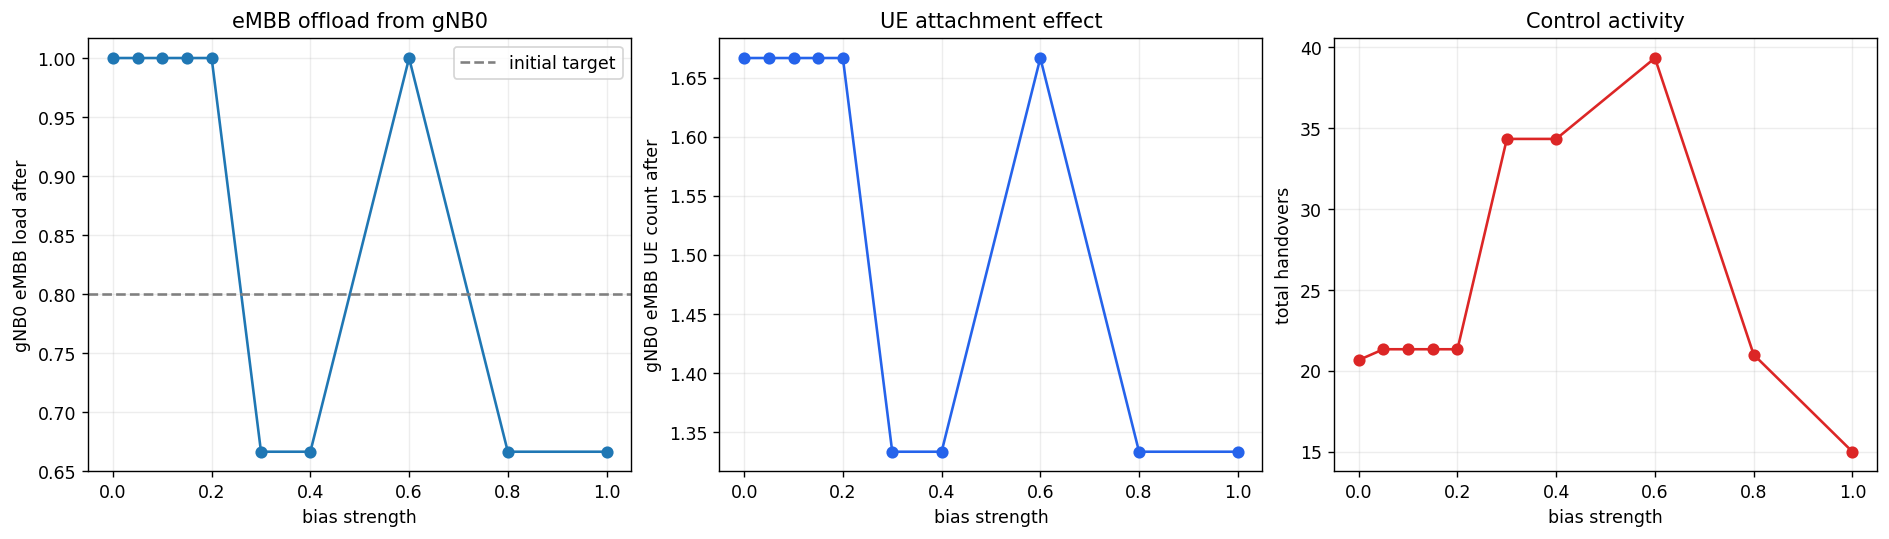

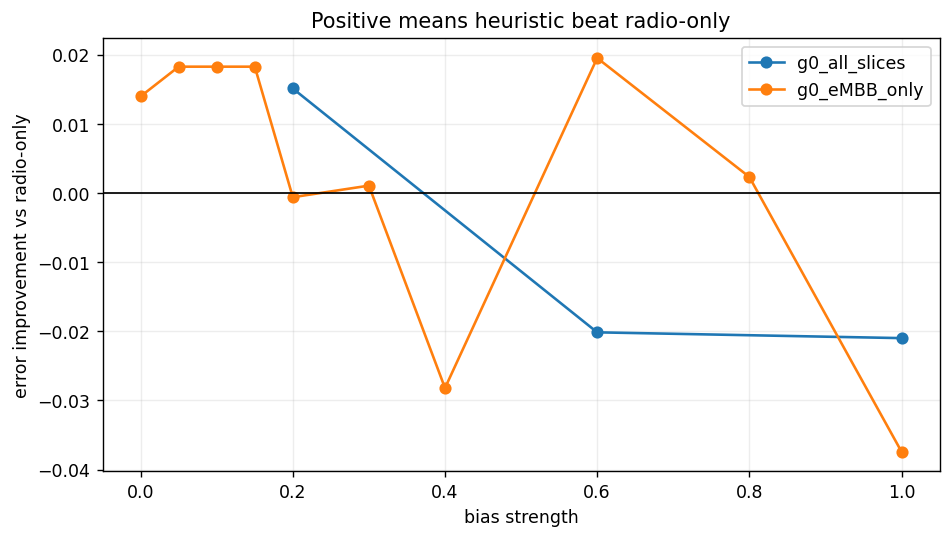

In [8]:
plot_df = summary_mean[summary_mean["family"] == "g0_eMBB_only"].sort_values("strength")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
axes[0].plot(plot_df["strength"], plot_df["g0_eMBB_load_after"], marker="o")
axes[0].axhline(target_matrix[0, 0], color="gray", linestyle="--", label="initial target")
axes[0].set_xlabel("bias strength")
axes[0].set_ylabel("gNB0 eMBB load after")
axes[0].set_title("eMBB offload from gNB0")
axes[0].legend()

axes[1].plot(plot_df["strength"], plot_df["g0_eMBB_ue_count_after"], marker="o", color="#2563eb")
axes[1].set_xlabel("bias strength")
axes[1].set_ylabel("gNB0 eMBB UE count after")
axes[1].set_title("UE attachment effect")

axes[2].plot(plot_df["strength"], plot_df["total_handovers"], marker="o", color="#dc2626")
axes[2].set_xlabel("bias strength")
axes[2].set_ylabel("total handovers")
axes[2].set_title("Control activity")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
for family, rows in summary_mean.groupby("family"):
    rows = rows.sort_values("strength")
    ax.plot(rows["strength"], rows["error_vs_radio"], marker="o", label=family)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xlabel("bias strength")
ax.set_ylabel("error improvement vs radio-only")
ax.set_title("Positive means heuristic beat radio-only")
ax.legend()
plt.show()

## Inspect One Test In Detail

## Progressive Soft Offload Tests

These tests are intentionally less aggressive than a constant `-1/+1` bias. They either decay smoothly back to zero or apply a short pulse and then stop. This helps find the smallest intervention that changes gNB0/eMBB without emptying it.

In [9]:
def decay_schedule(start_strength, windows=N_WINDOWS):
    if windows <= 1:
        return [g0_embb_bias(start_strength)]
    return [g0_embb_bias(start_strength * (1.0 - w / (windows - 1))) for w in range(windows)]

def pulse_schedule(strength, active_windows, windows=N_WINDOWS):
    return [g0_embb_bias(strength if w < active_windows else 0.0) for w in range(windows)]

SCHEDULE_TESTS = [
    {"test": "decay_0.20_to_0", "family": "progressive_decay", "strength": 0.20, "schedule": decay_schedule(0.20)},
    {"test": "decay_0.30_to_0", "family": "progressive_decay", "strength": 0.30, "schedule": decay_schedule(0.30)},
    {"test": "decay_0.40_to_0", "family": "progressive_decay", "strength": 0.40, "schedule": decay_schedule(0.40)},
    {"test": "pulse_0.20_one_window", "family": "short_pulse", "strength": 0.20, "schedule": pulse_schedule(0.20, 1)},
    {"test": "pulse_0.30_one_window", "family": "short_pulse", "strength": 0.30, "schedule": pulse_schedule(0.30, 1)},
    {"test": "pulse_0.30_two_windows", "family": "short_pulse", "strength": 0.30, "schedule": pulse_schedule(0.30, 2)},
    {"test": "pulse_0.40_two_windows", "family": "short_pulse", "strength": 0.40, "schedule": pulse_schedule(0.40, 2)},
]

display(pd.DataFrame([{k: v for k, v in test.items() if k != "schedule"} for test in SCHEDULE_TESTS]))

,test,family,strength
0,decay_0.20_to_0,progressive_decay,0.2
1,decay_0.30_to_0,progressive_decay,0.3
2,decay_0.40_to_0,progressive_decay,0.4
3,pulse_0.20_one_window,short_pulse,0.2
4,pulse_0.30_one_window,short_pulse,0.3
5,pulse_0.30_two_windows,short_pulse,0.3
6,pulse_0.40_two_windows,short_pulse,0.4


In [10]:
def run_heuristic_schedule(seed, test_name, schedule):
    env = make_env(seed)
    rows = []
    offset_rows = []
    try:
        obs, info = reset_custom_scenario(env)
        initial_load = env._load_matrix().copy()
        initial_counts = ue_count_matrix(env)
        initial_used = prb_used_matrix(env)
        for window in range(N_WINDOWS):
            bias_matrix = np.asarray(schedule[min(window, len(schedule) - 1)], dtype=float)
            before = env._load_matrix().copy()
            before_error = env._target_load_error(before)
            offset_rows.extend(collect_offset_snapshot(env, bias_matrix, window, test_name, seed))
            obs, reward, terminated, truncated, info = env.step(bias_matrix.reshape(-1))
            after = np.asarray(info["load_matrix"], dtype=float)
            rows.append({
                "seed": seed,
                "test": test_name,
                "window": window,
                "applied_strength": float(abs(bias_matrix[0, 0])),
                "reward": float(reward),
                "error_before": float(before_error),
                "error_after": float(info["target_load_error"]),
                "error_delta": float(before_error - float(info["target_load_error"])),
                "handover_count": int(info["handover_count"]),
                "sla_count": float(info["sla_count"]),
                "mean_abs_load_change": float(np.mean(np.abs(after - before))),
                "g0_eMBB_load_after": float(after[0, 0]),
                "g0_eMBB_ue_count_after": float(ue_count_matrix(env)[0, 0]),
            })
            if terminated or truncated:
                break
        final_load = env._load_matrix().copy()
        final_counts = ue_count_matrix(env)
        final_used = prb_used_matrix(env)
    finally:
        env.close()
    return {
        "history": pd.DataFrame(rows),
        "offsets": pd.DataFrame(offset_rows),
        "initial_load": initial_load,
        "final_load": final_load,
        "initial_counts": initial_counts,
        "final_counts": final_counts,
        "initial_used": initial_used,
        "final_used": final_used,
    }

schedule_results = {}
for spec in SCHEDULE_TESTS:
    for seed in SEEDS:
        schedule_results[(spec["test"], seed)] = run_heuristic_schedule(seed, spec["test"], spec["schedule"])

schedule_summary_rows = []
schedule_histories = []
for spec in SCHEDULE_TESTS:
    for seed in SEEDS:
        result = schedule_results[(spec["test"], seed)]
        radio = radio_by_seed[seed]
        hist = result["history"].copy()
        hist["family"] = spec["family"]
        hist["strength"] = spec["strength"]
        hist["radio_error_after"] = radio["history"]["error_after"].to_numpy()[:len(hist)]
        hist["radio_abs_load_change"] = radio["history"]["mean_abs_load_change"].to_numpy()[:len(hist)]
        hist["extra_abs_load_change"] = hist["mean_abs_load_change"] - hist["radio_abs_load_change"]
        schedule_histories.append(hist)

        radio_delta = radio["final_load"] - radio["initial_load"]
        heur_delta = result["final_load"] - result["initial_load"]
        extra_effect = heur_delta - radio_delta
        schedule_summary_rows.append({
            "test": spec["test"],
            "family": spec["family"],
            "strength": spec["strength"],
            "seed": seed,
            "radio_final_error": float(radio["history"]["error_after"].iloc[-1]),
            "heuristic_final_error": float(hist["error_after"].iloc[-1]),
            "error_vs_radio": float(radio["history"]["error_after"].iloc[-1] - hist["error_after"].iloc[-1]),
            "total_handovers": int(hist["handover_count"].sum()),
            "mean_sla_count": float(hist["sla_count"].mean()),
            "mean_abs_offset_effect": float(np.mean(np.abs(extra_effect))),
            "g0_eMBB_load_after": float(result["final_load"][0, 0]),
            "g0_eMBB_ue_count_after": float(result["final_counts"][0, 0]),
            "g0_eMBB_ue_count_delta": float(result["final_counts"][0, 0] - result["initial_counts"][0, 0]),
        })

schedule_summary_df = pd.DataFrame(schedule_summary_rows)
schedule_history_df = pd.concat(schedule_histories, ignore_index=True)
schedule_summary_mean = schedule_summary_df.groupby(["family", "strength", "test"], as_index=False).mean(numeric_only=True)
display(schedule_summary_mean.sort_values(["family", "strength"]))

,family,strength,test,seed,radio_final_error,heuristic_final_error,error_vs_radio,total_handovers,mean_sla_count,mean_abs_offset_effect,g0_eMBB_load_after,g0_eMBB_ue_count_after,g0_eMBB_ue_count_delta
0,progressive_decay,0.2,decay_0.20_to_0,12.333333,0.160543,0.164427,-0.003884,21.333333,0.388889,0.090909,1.0,1.666667,-1.333333
1,progressive_decay,0.3,decay_0.30_to_0,12.333333,0.160543,0.176235,-0.015692,22.666667,0.277778,0.086420,1.0,1.666667,-1.333333
2,progressive_decay,0.4,decay_0.40_to_0,12.333333,0.160543,0.144055,0.016488,25.333333,0.222222,0.096521,1.0,1.666667,-1.333333
3,short_pulse,0.2,pulse_0.20_one_window,12.333333,0.160543,0.170793,-0.010251,21.333333,0.277778,0.120090,1.0,1.666667,-1.333333
4,short_pulse,0.3,pulse_0.30_one_window,12.333333,0.160543,0.143728,0.016815,22.666667,0.222222,0.078563,1.0,1.666667,-1.333333
5,short_pulse,0.3,pulse_0.30_two_windows,12.333333,0.160543,0.147048,0.013495,26.000000,0.277778,0.094276,1.0,1.666667,-1.333333
6,short_pulse,0.4,pulse_0.40_two_windows,12.333333,0.160543,0.140463,0.020080,26.000000,0.444444,0.089787,1.0,1.666667,-1.333333


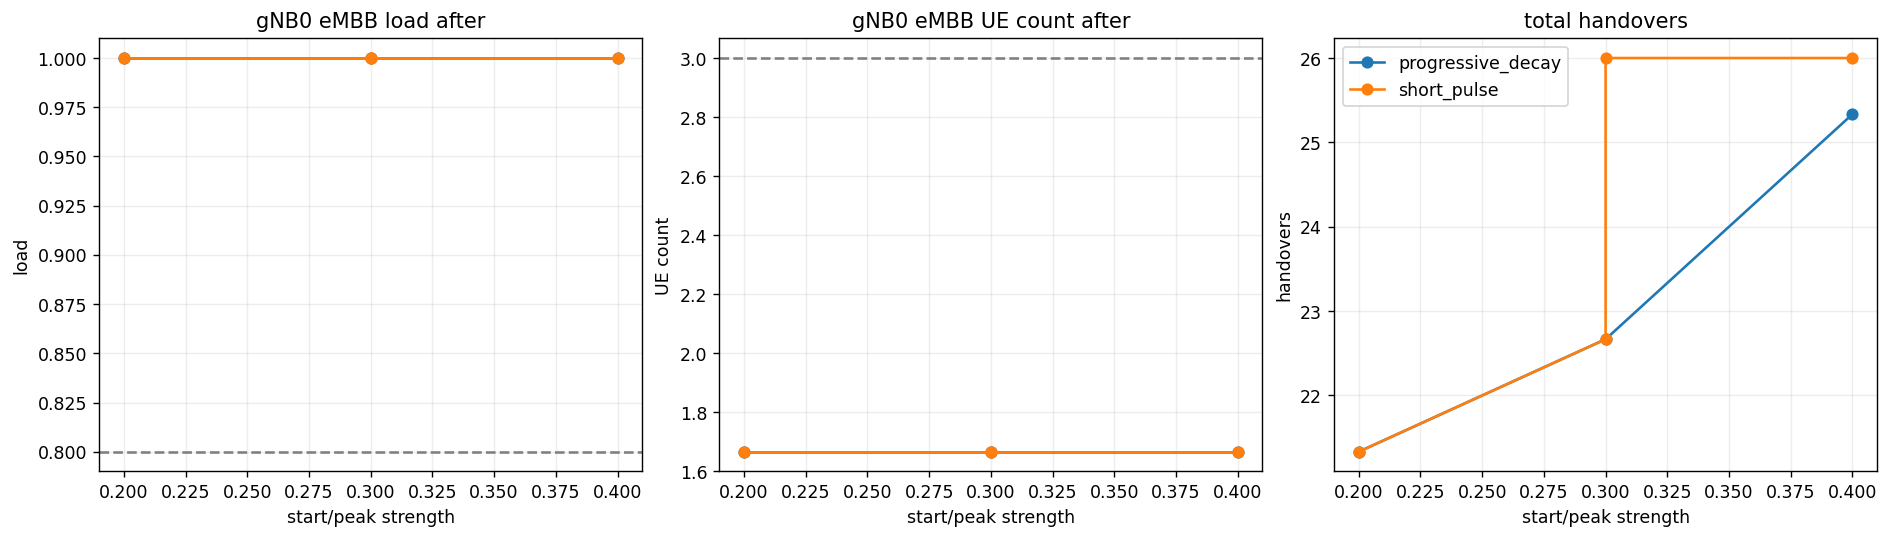

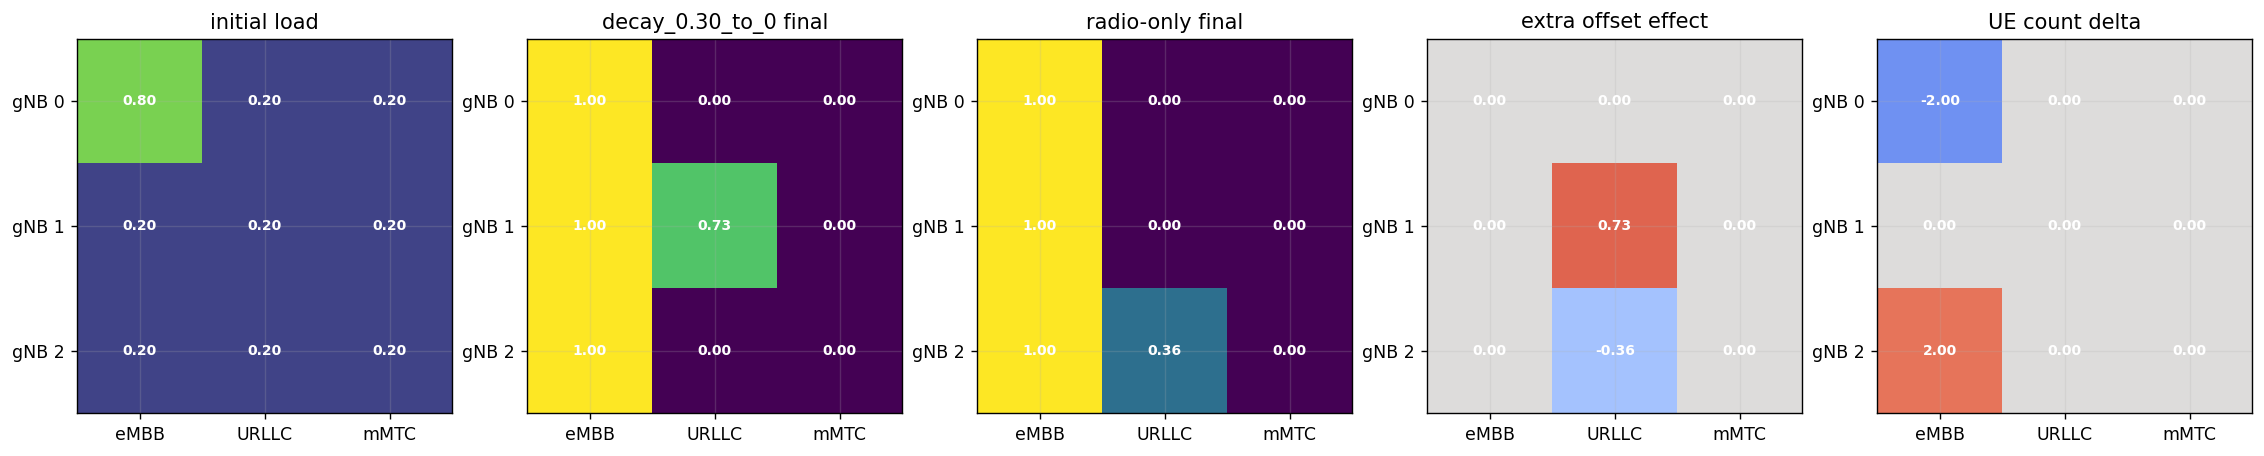

,seed,test,window,applied_strength,reward,error_before,error_after,error_delta,handover_count,sla_count,mean_abs_load_change,g0_eMBB_load_after,g0_eMBB_ue_count_after
0,7,decay_0.30_to_0,0,0.30,-1.865691,0.026667,0.146667,-0.120000,10,1.0,0.333333,1.0,1.0
1,7,decay_0.30_to_0,1,0.24,-0.565201,0.146667,0.205497,-0.058831,10,0.0,0.158249,1.0,1.0
2,7,decay_0.30_to_0,2,0.18,-0.304203,0.205497,0.146667,0.058831,10,0.0,0.158249,1.0,1.0
3,7,decay_0.30_to_0,3,0.12,-0.339640,0.146667,0.203538,-0.056872,10,0.0,0.144781,1.0,1.0
4,7,decay_0.30_to_0,4,0.06,-0.317139,0.203538,0.150585,0.052954,10,0.0,0.124579,1.0,1.0
5,7,decay_0.30_to_0,5,0.00,-0.324266,0.150585,0.173113,-0.022528,10,0.0,0.087542,1.0,1.0


,seed,test,window,from_gnb,to_gnb,slice,bias,serving_load,neighbor_load,proto_offset_db,applied_offset_db
0,7,decay_0.30_to_0,0,0,1,eMBB,-0.30,0.8,0.2,-3.373333,-4.0
1,7,decay_0.30_to_0,0,0,2,eMBB,-0.30,0.8,0.2,-3.373333,-4.0
6,7,decay_0.30_to_0,0,1,0,eMBB,0.30,0.2,0.8,3.920000,4.0
7,7,decay_0.30_to_0,0,1,2,eMBB,0.30,0.2,0.2,0.886667,0.0
12,7,decay_0.30_to_0,0,2,0,eMBB,0.30,0.2,0.8,3.920000,4.0
13,7,decay_0.30_to_0,0,2,1,eMBB,0.30,0.2,0.2,0.886667,0.0
18,7,decay_0.30_to_0,1,0,1,eMBB,-0.24,1.0,1.0,-0.781333,0.0
19,7,decay_0.30_to_0,1,0,2,eMBB,-0.24,1.0,1.0,0.752000,0.0
24,7,decay_0.30_to_0,1,1,0,eMBB,0.24,1.0,1.0,-0.565333,0.0
25,7,decay_0.30_to_0,1,1,2,eMBB,0.24,1.0,1.0,2.168000,2.0


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for family, rows in schedule_summary_mean.groupby("family"):
    rows = rows.sort_values("strength")
    axes[0].plot(rows["strength"], rows["g0_eMBB_load_after"], marker="o", label=family)
    axes[1].plot(rows["strength"], rows["g0_eMBB_ue_count_after"], marker="o", label=family)
    axes[2].plot(rows["strength"], rows["total_handovers"], marker="o", label=family)

axes[0].axhline(target_matrix[0, 0], color="gray", linestyle="--")
axes[0].set_title("gNB0 eMBB load after")
axes[0].set_xlabel("start/peak strength")
axes[0].set_ylabel("load")

axes[1].axhline(CUSTOM_UE_COUNTS.iloc[0, 0], color="gray", linestyle="--")
axes[1].set_title("gNB0 eMBB UE count after")
axes[1].set_xlabel("start/peak strength")
axes[1].set_ylabel("UE count")

axes[2].set_title("total handovers")
axes[2].set_xlabel("start/peak strength")
axes[2].set_ylabel("handovers")
axes[2].legend()
plt.show()

SOFT_DETAIL_TEST = "decay_0.30_to_0"
SOFT_DETAIL_SEED = SEEDS[0]
soft_detail = schedule_results[(SOFT_DETAIL_TEST, SOFT_DETAIL_SEED)]
soft_radio = radio_by_seed[SOFT_DETAIL_SEED]
soft_extra = (soft_detail["final_load"] - soft_detail["initial_load"]) - (soft_radio["final_load"] - soft_radio["initial_load"])

fig, axes = plt.subplots(1, 5, figsize=(18, 4), constrained_layout=True)
heatmap(axes[0], soft_detail["initial_load"], "initial load", cmap="viridis", vmin=0, vmax=1)
heatmap(axes[1], soft_detail["final_load"], f"{SOFT_DETAIL_TEST} final", cmap="viridis", vmin=0, vmax=1)
heatmap(axes[2], soft_radio["final_load"], "radio-only final", cmap="viridis", vmin=0, vmax=1)
heatmap(axes[3], soft_extra, "extra offset effect", cmap="coolwarm", vmin=-1, vmax=1)
heatmap(axes[4], soft_detail["final_counts"] - soft_detail["initial_counts"], "UE count delta", cmap="coolwarm", vmin=-3, vmax=3)
plt.show()

display(soft_detail["history"])
display(soft_detail["offsets"].query("slice == 'eMBB'").head(36))

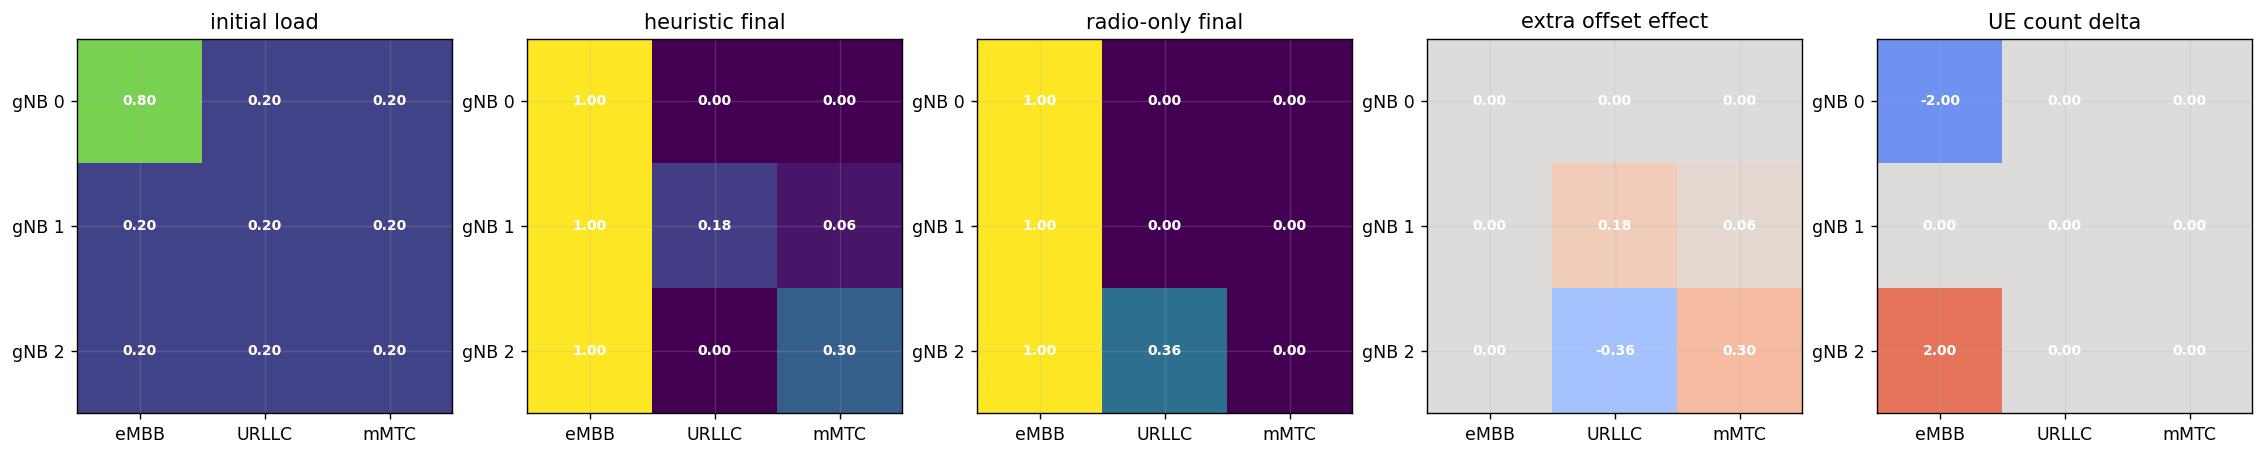

,seed,test,window,reward,error_before,error_after,error_delta,handover_count,sla_count,mean_abs_load_change
0,7,g0_eMBB_strength_0.6,0,-1.306749,0.026667,0.191111,-0.164444,9,0.0,0.466667
1,7,g0_eMBB_strength_0.6,1,-0.348068,0.191111,0.186703,0.004408,10,0.0,0.020202
2,7,g0_eMBB_strength_0.6,2,-0.349963,0.186703,0.191111,-0.004408,10,0.0,0.020202
3,7,g0_eMBB_strength_0.6,3,-0.372873,0.191111,0.202396,-0.011285,9,0.0,0.387205
4,7,g0_eMBB_strength_0.6,4,-0.380149,0.202396,0.182581,0.019814,10,0.0,0.225589
5,7,g0_eMBB_strength_0.6,5,-0.363729,0.182581,0.136708,0.045873,10,0.0,0.175084


,seed,test,window,from_gnb,to_gnb,slice,bias,serving_load,neighbor_load,proto_offset_db,applied_offset_db
0,7,g0_eMBB_strength_0.6,0,0,1,eMBB,-0.6,0.8,0.2,-4.273333,-4.0
1,7,g0_eMBB_strength_0.6,0,0,2,eMBB,-0.6,0.8,0.2,-4.273333,-4.0
6,7,g0_eMBB_strength_0.6,0,1,0,eMBB,0.6,0.2,0.8,5.180000,6.0
7,7,g0_eMBB_strength_0.6,0,1,2,eMBB,0.6,0.2,0.2,2.146667,2.0
12,7,g0_eMBB_strength_0.6,0,2,0,eMBB,0.6,0.2,0.8,5.180000,6.0
13,7,g0_eMBB_strength_0.6,0,2,1,eMBB,0.6,0.2,0.2,2.146667,2.0
18,7,g0_eMBB_strength_0.6,1,0,1,eMBB,-0.6,0.0,1.0,2.993333,2.0
19,7,g0_eMBB_strength_0.6,1,0,2,eMBB,-0.6,0.0,1.0,4.060000,4.0
24,7,g0_eMBB_strength_0.6,1,1,0,eMBB,0.6,1.0,0.0,-1.220000,-2.0
25,7,g0_eMBB_strength_0.6,1,1,2,eMBB,0.6,1.0,1.0,4.280000,4.0


Initial PRBs used


,eMBB,URLLC,mMTC
gNB 0,16.0,3.0,1.0
gNB 1,4.0,3.0,1.0
gNB 2,4.0,3.0,1.0


Final PRBs used


,eMBB,URLLC,mMTC
gNB 0,100.0,0.0,0.0
gNB 1,92.0,6.0,2.0
gNB 2,90.0,0.0,10.0


PRB budget


,eMBB,URLLC,mMTC
gNB 0,20.0,15.0,5.0
gNB 1,20.0,15.0,5.0
gNB 2,20.0,15.0,5.0


In [12]:
DETAIL_TEST = "g0_eMBB_strength_0.6"
DETAIL_SEED = SEEDS[0]

detail = heuristic_results[(DETAIL_TEST, DETAIL_SEED)]
radio = radio_by_seed[DETAIL_SEED]
radio_delta = radio["final_load"] - radio["initial_load"]
heur_delta = detail["final_load"] - detail["initial_load"]
extra_effect = heur_delta - radio_delta

fig, axes = plt.subplots(1, 5, figsize=(18, 4), constrained_layout=True)
heatmap(axes[0], detail["initial_load"], "initial load", cmap="viridis", vmin=0, vmax=1)
heatmap(axes[1], detail["final_load"], "heuristic final", cmap="viridis", vmin=0, vmax=1)
heatmap(axes[2], radio["final_load"], "radio-only final", cmap="viridis", vmin=0, vmax=1)
heatmap(axes[3], extra_effect, "extra offset effect", cmap="coolwarm", vmin=-1, vmax=1)
heatmap(axes[4], detail["final_counts"] - detail["initial_counts"], "UE count delta", cmap="coolwarm", vmin=-3, vmax=3)
plt.show()

display(detail["history"])
display(detail["offsets"].query("slice == 'eMBB'").head(36))

print("Initial PRBs used")
display(matrix_df(detail["initial_used"]))
print("Final PRBs used")
display(matrix_df(detail["final_used"]))
print("PRB budget")
tmp_env = make_env(DETAIL_SEED)
try:
    reset_custom_scenario(tmp_env)
    display(matrix_df(prb_budget_matrix(tmp_env)))
finally:
    tmp_env.close()